# Imports

In [1]:
import os
import glob
import json
import numpy as np
import openslide
import pdnl_sana as sana
import pdnl_sana.image
from Helper_Functions.loading import get_neuseg_results, get_manual_results

# Loading & Environment Setting Up

In [2]:
# Directory Path set-up
data_dir = '/Volumes/Extreme SSD/Research/Projects/Individual Covariance Networks/Histopathology/NEUSEG_Experiment'
WSI_dir =           os.path.join(data_dir, 'bvFTD_Eval_cohort')
manual_annot_dir =  os.path.join(data_dir, 'quPath_Manual_Annotation')
neuseg_annot_dir =  os.path.join(data_dir, 'GM_WM_Seg_Results_bvFTD_WSIs_20260216_Eval_Cohort')

In [3]:
# WSI File Names (FTLD-TAU, FTLD-TDP)
TAU_svs_files = glob.glob(os.path.join(WSI_dir, "FTLD-TAU", "*.svs"))
TAU_svs_filenames = [os.path.basename(f) for f in TAU_svs_files]

TDP_svs_files = glob.glob(os.path.join(WSI_dir, "FTLD-TDP", "*.svs"))
TDP_svs_filenames = [os.path.basename(f) for f in TDP_svs_files]

print(f'Number of WSIs: FTLD-TAU={len(TAU_svs_filenames)} / FTLD-TDP={len(TDP_svs_filenames)}')

Number of WSIs: FTLD-TAU=222 / FTLD-TDP=336


full-res=37848x27583  thumb=2365x1723  scale=16.0034  mpp=0.5045
mask contours -> GM-WM: 2 polys | GM-CSF: 2 polys
geojson ROI 'GM_0': GM-WM (20, 2) | GM-CSF (20, 2)


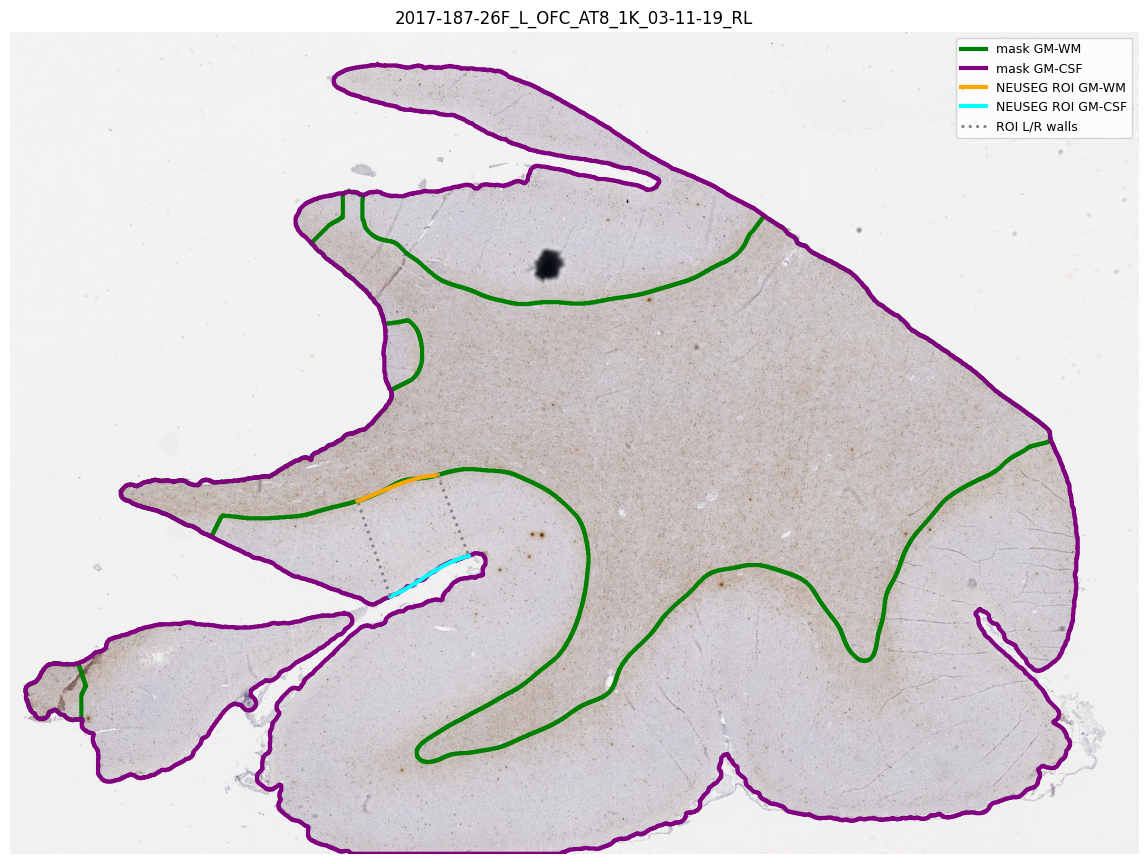

In [4]:
curr_slide_name = '2017-187-26F_L_OFC_AT8_1K_03-11-19_RL'

res = get_neuseg_results(curr_slide_name, neuseg_annot_dir, WSI_dir, verbose=True)

# unpack what you need
mask_gm_wm  = res["mask_gm_wm"]    # list of (N,2) full-res arrays  (WM outline)
mask_gm_csf = res["mask_gm_csf"]   # list of (M,2) full-res arrays  (tissue outline)
annot       = res["annot"]         # {roi: {'gm_wm': (N,2), 'gm_csf': (M,2)}} full-res
svs_path    = res["svs_path"]
scale, mpp  = res["scale"], res["mpp"]

manual ROI 'ROI': GM-WM (2, 2) | GM-CSF (2, 2) 


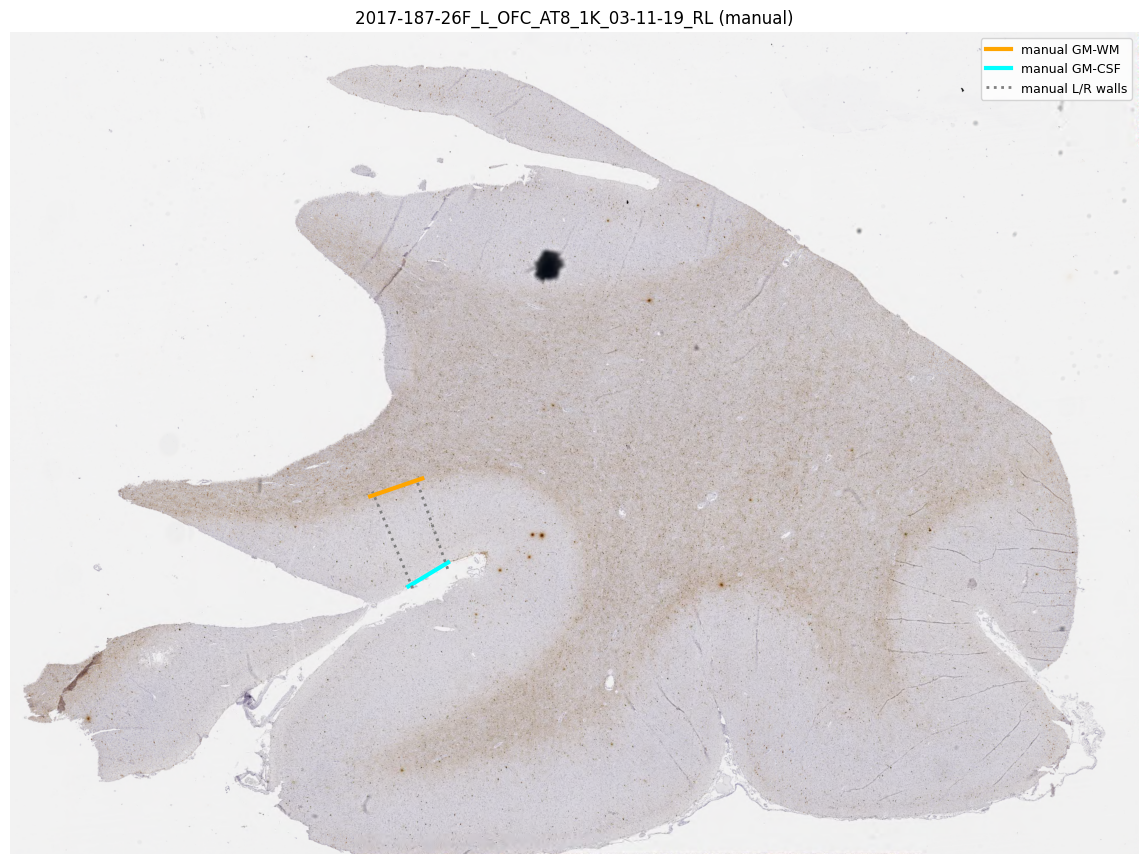

In [5]:
man = get_manual_results(curr_slide_name, manual_annot_dir, WSI_dir, verbose=True)  # prints + figure
#man = get_manual_results(curr_slide_name, manual_annot_dir, verbose=True)           # prints only, no figure


# Evaluation Block

### [1] Annotation-to-Contour Distance